<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/CPW_Field_Magpylib_and_K3D_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!pip install -q "numpy>=2.0" k3d trimesh magpylib
!pip install -q ipywidgets

# Enable Colab widget support
from google.colab import output
output.enable_custom_widget_manager()

In [2]:
"""Render quasi-TEM electric and magnetic fields around a 3D CPW."""

import sys

import k3d
import matplotlib.pyplot as plt
import numpy as np

from google.colab import output
from IPython.display import HTML, display


# ------------------------------------------------------------
# COLAB CONFIGURATION
# ------------------------------------------------------------

output.enable_custom_widget_manager()


def configure_k3d_snapshot_protocol():
    """Enable K3D text serialization where supported."""
    switch_protocol = getattr(k3d, "switch_to_text_protocol", None)

    if callable(switch_protocol):
        switch_protocol()


configure_k3d_snapshot_protocol()


# ------------------------------------------------------------
# CONTROL KNOBS - CPW GEOMETRY
# ------------------------------------------------------------

# The defaults follow the straight CPW dimensions discussed in the supplied
# paper: 0.700 mm center strip and 3.400 mm inter-ground distance.
CPW_CENTER_WIDTH_MM = 0.700
CPW_INTERGROUND_DISTANCE_MM = 3.400
CPW_GROUND_WIDTH_MM = 3.000
CPW_LENGTH_MM = 12.000

# The paper gives a 1.52 mm FR4 substrate thickness and epsilon_r = 5.4.
SUBSTRATE_THICKNESS_MM = 1.520
SUBSTRATE_RELATIVE_PERMITTIVITY = 5.4
SUBSTRATE_SIDE_MARGIN_MM = 1.000

# Rendering thickness for the metal. This value is user adjustable.
METAL_THICKNESS_MM = 0.035


# ------------------------------------------------------------
# CONTROL KNOBS - QUASI-TEM EXCITATION
# ------------------------------------------------------------

SIGNAL_VOLTAGE_V = 1.0
GROUND_VOLTAGE_V = 0.0
FREQUENCY_GHZ = 2.4

# Homogeneous effective-medium approximation for air above and substrate below.
# Set a numeric value to override the default arithmetic estimate.
EFFECTIVE_RELATIVE_PERMITTIVITY_OVERRIDE = None

# Set a numeric value to override the ideal conformal-mapping Z0 estimate.
CHARACTERISTIC_IMPEDANCE_OVERRIDE_OHM = None


# ------------------------------------------------------------
# CONTROL KNOBS - ELECTROSTATIC PANEL MODEL
# ------------------------------------------------------------

CENTER_CONDUCTOR_PANELS = 32
GROUND_CONDUCTOR_PANELS_EACH = 48

# Self-distance used to regularize each 2D logarithmic line-charge panel.
PANEL_SELF_RADIUS_FACTOR = 1.0 / (2.0 * np.e)
LOG_REFERENCE_DISTANCE_M = 1.0


# ------------------------------------------------------------
# CONTROL KNOBS - GAP-FOCUSED FIELD SAMPLING
# ------------------------------------------------------------

FIELD_CANDIDATE_POINTS = 5200
FIELD_HALTON_SKIP = 43

FIELD_Z_MIN_MM = -1.20
FIELD_Z_MAX_MM = 1.20
FIELD_X_OUTER_MARGIN_MM = 0.70

# Keep arrows concentrated around the two CPW gaps and the adjacent edges.
GAP_FOCUS_ONLY = True
GAP_FOCUS_MARGIN_MM = 0.34

# Remove samples too close to the idealized zero-thickness panel source plane.
SOURCE_CLEARANCE_MM = 0.045

# Stronger fields receive smaller local blue-noise spacing.
ADAPTIVE_SPACING_MIN_MM = 0.18
ADAPTIVE_SPACING_MAX_MM = 0.43
ADAPTIVE_FIELD_MIN_PERCENTILE = 4.0
ADAPTIVE_FIELD_MAX_PERCENTILE = 98.0
ADAPTIVE_SPACING_EXPONENT = 0.62

# Replicate one solved transverse cross-section along the uniform CPW length.
FIELD_LONGITUDINAL_SLICES = 7
FIELD_LONGITUDINAL_END_MARGIN = 0.10

SHOW_SAMPLING_DIAGNOSTICS = True


# ------------------------------------------------------------
# CONTROL KNOBS - FIELD-DEPENDENT ARROW GEOMETRY
# ------------------------------------------------------------

GLYPH_FIELD_MIN_PERCENTILE = 3.0
GLYPH_FIELD_MAX_PERCENTILE = 98.0
GLYPH_SIZE_EXPONENT = 0.62

GLYPH_SCALE_MIN = 0.35
GLYPH_SCALE_MAX = 1.45

BASE_ARROW_LENGTH_MM = 0.34
BASE_ARROW_SHAFT_DIAMETER_MM = 0.060
BASE_ARROW_CONE_LENGTH_MM = 0.115
BASE_ARROW_CONE_RADIUS_MM = 0.080

ARROW_DIAMETER_SCALE = 0.70
ARROW_SHAFT_RADIAL_SEGMENTS = 10
ARROW_CONE_RADIAL_SEGMENTS = 10
ARROW_CONE_MAX_LENGTH_FRACTION = 0.44
ARROW_CONE_MAX_RADIUS_FRACTION = 0.31
ARROW_CONE_SHININESS = 35.0

# Expand conductor boxes during segment collision testing.
METAL_CLEARANCE_FACTOR = 1.08
METAL_EXTRA_CLEARANCE_MM = 0.015


# ------------------------------------------------------------
# CONTROL KNOBS - FIELD COLORS
# ------------------------------------------------------------

ELECTRIC_COLORMAP_NAME = "turbo"
MAGNETIC_COLORMAP_NAME = "turbo"
COLORMAP_SAMPLES = 256

ELECTRIC_COLOR_MIN_PERCENTILE = 2.0
ELECTRIC_COLOR_MAX_PERCENTILE = 99.0
MAGNETIC_COLOR_MIN_PERCENTILE = 2.0
MAGNETIC_COLOR_MAX_PERCENTILE = 99.0

SHOW_COLORBAR = True


# ------------------------------------------------------------
# CONTROL KNOBS - K3D SCENE
# ------------------------------------------------------------

PLOT_HEIGHT = 700
BACKGROUND_COLOR = 0xFFFFFF
GRID_COLOR = 0xD5D5D5
LABEL_COLOR = 0x111111
GRID_VISIBLE = True

SUBSTRATE_COLOR = 0xDCEEFF
SUBSTRATE_OPACITY = 0.28
CENTER_CONDUCTOR_COLOR = 0xC8842F
GROUND_CONDUCTOR_COLOR = 0x8A8A8A
METAL_OPACITY = 0.94

# "snapshot" is dependable in Google Colab.
# "widget" selects the standard K3D widget.
RENDER_MODE = "snapshot"
COMPRESSION_LEVEL = 9

CAMERA = [
    8.8,
    -12.5,
    7.8,
    0.0,
    0.0,
    -0.15,
    0.0,
    0.0,
    1.0,
]


# ------------------------------------------------------------
# CONSTANTS AND DERIVED GEOMETRY
# ------------------------------------------------------------

EPSILON_0 = 8.8541878128e-12
MU_0 = 4.0e-7 * np.pi
C_0 = 299_792_458.0
MM_TO_M = 1.0e-3
TESLA_TO_MICROTESLA = 1.0e6

CPW_CENTER_HALF_WIDTH_MM = 0.5 * CPW_CENTER_WIDTH_MM
CPW_INNER_GROUND_EDGE_MM = 0.5 * CPW_INTERGROUND_DISTANCE_MM
CPW_GAP_MM = CPW_INNER_GROUND_EDGE_MM - CPW_CENTER_HALF_WIDTH_MM

LEFT_GROUND_X_MIN_MM = -(
    CPW_INNER_GROUND_EDGE_MM + CPW_GROUND_WIDTH_MM
)
LEFT_GROUND_X_MAX_MM = -CPW_INNER_GROUND_EDGE_MM
RIGHT_GROUND_X_MIN_MM = CPW_INNER_GROUND_EDGE_MM
RIGHT_GROUND_X_MAX_MM = CPW_INNER_GROUND_EDGE_MM + CPW_GROUND_WIDTH_MM

SUBSTRATE_WIDTH_MM = 2.0 * (
    CPW_INNER_GROUND_EDGE_MM
    + CPW_GROUND_WIDTH_MM
    + SUBSTRATE_SIDE_MARGIN_MM
)

FIELD_X_MAX_MM = (
    CPW_INNER_GROUND_EDGE_MM + FIELD_X_OUTER_MARGIN_MM
)
FIELD_X_MIN_MM = -FIELD_X_MAX_MM

PANEL_SOURCE_Z_MM = METAL_THICKNESS_MM


# ------------------------------------------------------------
# INPUT CHECKS
# ------------------------------------------------------------


def validate_controls():
    """Check geometric and numerical controls before solving fields."""
    positive_values = {
        "CPW_CENTER_WIDTH_MM": CPW_CENTER_WIDTH_MM,
        "CPW_INTERGROUND_DISTANCE_MM": CPW_INTERGROUND_DISTANCE_MM,
        "CPW_GROUND_WIDTH_MM": CPW_GROUND_WIDTH_MM,
        "CPW_LENGTH_MM": CPW_LENGTH_MM,
        "SUBSTRATE_THICKNESS_MM": SUBSTRATE_THICKNESS_MM,
        "SUBSTRATE_RELATIVE_PERMITTIVITY": SUBSTRATE_RELATIVE_PERMITTIVITY,
        "METAL_THICKNESS_MM": METAL_THICKNESS_MM,
        "SIGNAL_VOLTAGE_V": SIGNAL_VOLTAGE_V,
        "FIELD_CANDIDATE_POINTS": FIELD_CANDIDATE_POINTS,
        "FIELD_LONGITUDINAL_SLICES": FIELD_LONGITUDINAL_SLICES,
    }

    for name, value in positive_values.items():
        if float(value) <= 0.0:
            raise ValueError(f"{name} must be positive.")

    if CPW_GAP_MM <= 0.0:
        raise ValueError(
            "CPW_INTERGROUND_DISTANCE_MM must exceed CPW_CENTER_WIDTH_MM."
        )

    if FIELD_Z_MAX_MM <= FIELD_Z_MIN_MM:
        raise ValueError("FIELD_Z_MAX_MM must exceed FIELD_Z_MIN_MM.")

    if ADAPTIVE_SPACING_MAX_MM < ADAPTIVE_SPACING_MIN_MM:
        raise ValueError(
            "ADAPTIVE_SPACING_MAX_MM must equal or exceed the minimum spacing."
        )


validate_controls()


# ------------------------------------------------------------
# EFFECTIVE MEDIUM AND CHARACTERISTIC IMPEDANCE
# ------------------------------------------------------------


def complete_elliptic_integral_first_kind_agm(modulus):
    """Return K(k) using the arithmetic-geometric mean algorithm."""
    modulus = float(modulus)

    if modulus < 0.0 or modulus >= 1.0:
        raise ValueError("Elliptic modulus must satisfy 0 <= k < 1.")

    arithmetic = 1.0
    geometric = np.sqrt(1.0 - modulus * modulus)

    for _ in range(80):
        next_arithmetic = 0.5 * (arithmetic + geometric)
        next_geometric = np.sqrt(arithmetic * geometric)

        if abs(next_arithmetic - next_geometric) <= 1.0e-15:
            arithmetic = next_arithmetic
            break

        arithmetic = next_arithmetic
        geometric = next_geometric

    return np.pi / (2.0 * arithmetic)


def resolve_effective_relative_permittivity():
    """Return the selected effective relative permittivity."""
    if EFFECTIVE_RELATIVE_PERMITTIVITY_OVERRIDE is None:
        return 0.5 * (1.0 + SUBSTRATE_RELATIVE_PERMITTIVITY)

    value = float(EFFECTIVE_RELATIVE_PERMITTIVITY_OVERRIDE)

    if value <= 0.0:
        raise ValueError(
            "EFFECTIVE_RELATIVE_PERMITTIVITY_OVERRIDE must be positive or None."
        )

    return value


def estimate_cpw_characteristic_impedance(epsilon_eff):
    """Estimate ideal CPW characteristic impedance by conformal mapping."""
    if CHARACTERISTIC_IMPEDANCE_OVERRIDE_OHM is None:
        modulus = CPW_CENTER_WIDTH_MM / CPW_INTERGROUND_DISTANCE_MM
        complementary_modulus = np.sqrt(1.0 - modulus * modulus)

        k_value = complete_elliptic_integral_first_kind_agm(modulus)
        kp_value = complete_elliptic_integral_first_kind_agm(
            complementary_modulus
        )

        return (
            30.0
            * np.pi
            / np.sqrt(epsilon_eff)
            * kp_value
            / k_value
        )

    value = float(CHARACTERISTIC_IMPEDANCE_OVERRIDE_OHM)

    if value <= 0.0:
        raise ValueError(
            "CHARACTERISTIC_IMPEDANCE_OVERRIDE_OHM must be positive or None."
        )

    return value


EPSILON_EFFECTIVE_R = resolve_effective_relative_permittivity()
EPSILON_EFFECTIVE = EPSILON_0 * EPSILON_EFFECTIVE_R
CPW_Z0_OHM = estimate_cpw_characteristic_impedance(EPSILON_EFFECTIVE_R)
SIGNAL_CURRENT_A = SIGNAL_VOLTAGE_V / CPW_Z0_OHM
PHASE_VELOCITY_M_PER_S = C_0 / np.sqrt(EPSILON_EFFECTIVE_R)
GUIDED_WAVELENGTH_MM = (
    PHASE_VELOCITY_M_PER_S
    / (FREQUENCY_GHZ * 1.0e9)
    / MM_TO_M
)


# ------------------------------------------------------------
# ENVIRONMENT AND MODEL DIAGNOSTICS
# ------------------------------------------------------------

print("Scientific Python environment")
print(f"  Python:      {sys.version.split()[0]}")
print(f"  NumPy:       {np.__version__}")
print(f"  K3D:         {k3d.__version__}")
print(f"  Matplotlib:  {plt.matplotlib.__version__}")

print("\nCPW geometry")
print(f"  Center width:          {CPW_CENTER_WIDTH_MM:.4f} mm")
print(f"  Gap width:             {CPW_GAP_MM:.4f} mm")
print(f"  Inter-ground distance: {CPW_INTERGROUND_DISTANCE_MM:.4f} mm")
print(f"  Substrate thickness:   {SUBSTRATE_THICKNESS_MM:.4f} mm")
print(f"  Substrate epsilon_r:   {SUBSTRATE_RELATIVE_PERMITTIVITY:.4f}")

print("\nQuasi-TEM model")
print(f"  Effective epsilon_r:   {EPSILON_EFFECTIVE_R:.6f}")
print(f"  Estimated Z0:          {CPW_Z0_OHM:.6f} ohm")
print(f"  Signal voltage:        {SIGNAL_VOLTAGE_V:.6f} V")
print(f"  Signal current:        {SIGNAL_CURRENT_A * 1.0e3:.6f} mA")
print(f"  Frequency:             {FREQUENCY_GHZ:.6f} GHz")
print(f"  Guided wavelength:     {GUIDED_WAVELENGTH_MM:.6f} mm")


# ------------------------------------------------------------
# CONDUCTOR PANEL DISCRETIZATION
# ------------------------------------------------------------


def make_uniform_panels(x_min_mm, x_max_mm, panel_count, voltage_v):
    """Return panel centers, widths, and target potentials for one conductor."""
    if panel_count < 2:
        raise ValueError("Each conductor requires at least two panels.")

    edges_mm = np.linspace(
        x_min_mm,
        x_max_mm,
        panel_count + 1,
        dtype=np.float64,
    )
    centers_mm = 0.5 * (edges_mm[:-1] + edges_mm[1:])
    widths_mm = np.diff(edges_mm)
    potentials_v = np.full(panel_count, voltage_v, dtype=np.float64)

    return centers_mm, widths_mm, potentials_v


left_x_mm, left_widths_mm, left_v = make_uniform_panels(
    LEFT_GROUND_X_MIN_MM,
    LEFT_GROUND_X_MAX_MM,
    GROUND_CONDUCTOR_PANELS_EACH,
    GROUND_VOLTAGE_V,
)
center_x_mm, center_widths_mm, center_v = make_uniform_panels(
    -CPW_CENTER_HALF_WIDTH_MM,
    CPW_CENTER_HALF_WIDTH_MM,
    CENTER_CONDUCTOR_PANELS,
    SIGNAL_VOLTAGE_V,
)
right_x_mm, right_widths_mm, right_v = make_uniform_panels(
    RIGHT_GROUND_X_MIN_MM,
    RIGHT_GROUND_X_MAX_MM,
    GROUND_CONDUCTOR_PANELS_EACH,
    GROUND_VOLTAGE_V,
)

PANEL_X_MM = np.concatenate((left_x_mm, center_x_mm, right_x_mm))
PANEL_WIDTHS_MM = np.concatenate(
    (left_widths_mm, center_widths_mm, right_widths_mm)
)
PANEL_TARGET_V = np.concatenate((left_v, center_v, right_v))

PANEL_X_M = PANEL_X_MM * MM_TO_M
PANEL_WIDTHS_M = PANEL_WIDTHS_MM * MM_TO_M
PANEL_SOURCE_Z_M = PANEL_SOURCE_Z_MM * MM_TO_M

LEFT_PANEL_SLICE = slice(0, GROUND_CONDUCTOR_PANELS_EACH)
CENTER_PANEL_SLICE = slice(
    GROUND_CONDUCTOR_PANELS_EACH,
    GROUND_CONDUCTOR_PANELS_EACH + CENTER_CONDUCTOR_PANELS,
)
RIGHT_PANEL_SLICE = slice(
    GROUND_CONDUCTOR_PANELS_EACH + CENTER_CONDUCTOR_PANELS,
    PANEL_X_MM.size,
)


# ------------------------------------------------------------
# 2D ELECTROSTATIC BOUNDARY-ELEMENT SOLVE
# ------------------------------------------------------------


def solve_line_charge_panels():
    """Solve panel line charges for the prescribed CPW conductor voltages."""
    panel_count = PANEL_X_M.size
    pair_distance_m = np.abs(
        PANEL_X_M[:, np.newaxis] - PANEL_X_M[np.newaxis, :]
    )

    self_distance_m = PANEL_SELF_RADIUS_FACTOR * PANEL_WIDTHS_M
    diagonal_indices = np.diag_indices(panel_count)
    pair_distance_m[diagonal_indices] = self_distance_m

    green_matrix = -(
        1.0 / (2.0 * np.pi * EPSILON_EFFECTIVE)
    ) * np.log(pair_distance_m / LOG_REFERENCE_DISTANCE_M)

    system_matrix = np.zeros(
        (panel_count + 1, panel_count + 1),
        dtype=np.float64,
    )
    right_hand_side = np.zeros(panel_count + 1, dtype=np.float64)

    system_matrix[:panel_count, :panel_count] = green_matrix
    system_matrix[:panel_count, panel_count] = 1.0
    system_matrix[panel_count, :panel_count] = 1.0

    right_hand_side[:panel_count] = PANEL_TARGET_V
    right_hand_side[panel_count] = 0.0

    solution = np.linalg.solve(system_matrix, right_hand_side)
    line_charges_c_per_m = solution[:panel_count]
    potential_offset_v = float(solution[panel_count])

    reconstructed_v = (
        green_matrix @ line_charges_c_per_m + potential_offset_v
    )
    maximum_voltage_error_v = float(
        np.max(np.abs(reconstructed_v - PANEL_TARGET_V))
    )

    return (
        line_charges_c_per_m,
        potential_offset_v,
        maximum_voltage_error_v,
    )


(
    PANEL_LINE_CHARGE_C_PER_M,
    PANEL_POTENTIAL_OFFSET_V,
    PANEL_MAX_VOLTAGE_ERROR_V,
) = solve_line_charge_panels()

CENTER_TOTAL_CHARGE_C_PER_M = float(
    np.sum(PANEL_LINE_CHARGE_C_PER_M[CENTER_PANEL_SLICE])
)
LEFT_TOTAL_CHARGE_C_PER_M = float(
    np.sum(PANEL_LINE_CHARGE_C_PER_M[LEFT_PANEL_SLICE])
)
RIGHT_TOTAL_CHARGE_C_PER_M = float(
    np.sum(PANEL_LINE_CHARGE_C_PER_M[RIGHT_PANEL_SLICE])
)

if CENTER_TOTAL_CHARGE_C_PER_M <= 0.0:
    raise RuntimeError("The solved center-conductor charge must be positive.")

# Quasi-TEM dual distribution: panel current follows the solved charge shape,
# then the complete center-conductor current is normalized to V / Z0.
PANEL_CURRENT_A = (
    SIGNAL_CURRENT_A
    * PANEL_LINE_CHARGE_C_PER_M
    / CENTER_TOTAL_CHARGE_C_PER_M
)

print("\nBoundary-element solve")
print(f"  Panels:                 {PANEL_X_MM.size:,}")
print(
    "  Maximum voltage error: "
    f"{PANEL_MAX_VOLTAGE_ERROR_V:.3e} V"
)
print(
    "  Center charge:          "
    f"{CENTER_TOTAL_CHARGE_C_PER_M:.6e} C/m"
)
print(
    "  Left ground charge:     "
    f"{LEFT_TOTAL_CHARGE_C_PER_M:.6e} C/m"
)
print(
    "  Right ground charge:    "
    f"{RIGHT_TOTAL_CHARGE_C_PER_M:.6e} C/m"
)
print(
    "  Net panel current:      "
    f"{np.sum(PANEL_CURRENT_A):.3e} A"
)


# ------------------------------------------------------------
# ELECTRIC AND MAGNETIC FIELD EVALUATORS
# ------------------------------------------------------------


def evaluate_electric_field(x_mm, z_mm):
    """Evaluate the 2D electric field generated by solved line charges."""
    x_m = np.asarray(x_mm, dtype=np.float64) * MM_TO_M
    z_m = np.asarray(z_mm, dtype=np.float64) * MM_TO_M

    delta_x_m = x_m[:, np.newaxis] - PANEL_X_M[np.newaxis, :]
    delta_z_m = z_m[:, np.newaxis] - PANEL_SOURCE_Z_M
    radius_squared_m2 = delta_x_m * delta_x_m + delta_z_m * delta_z_m
    radius_squared_m2 = np.maximum(radius_squared_m2, 1.0e-24)

    coefficient = (
        PANEL_LINE_CHARGE_C_PER_M[np.newaxis, :]
        / (2.0 * np.pi * EPSILON_EFFECTIVE)
    )

    e_x_v_per_m = np.sum(
        coefficient * delta_x_m / radius_squared_m2,
        axis=1,
    )
    e_z_v_per_m = np.sum(
        coefficient * delta_z_m / radius_squared_m2,
        axis=1,
    )

    return np.column_stack(
        (
            e_x_v_per_m,
            np.zeros_like(e_x_v_per_m),
            e_z_v_per_m,
        )
    )


def evaluate_magnetic_flux_density(x_mm, z_mm):
    """Evaluate B from equivalent longitudinal panel currents."""
    x_m = np.asarray(x_mm, dtype=np.float64) * MM_TO_M
    z_m = np.asarray(z_mm, dtype=np.float64) * MM_TO_M

    delta_x_m = x_m[:, np.newaxis] - PANEL_X_M[np.newaxis, :]
    delta_z_m = z_m[:, np.newaxis] - PANEL_SOURCE_Z_M
    radius_squared_m2 = delta_x_m * delta_x_m + delta_z_m * delta_z_m
    radius_squared_m2 = np.maximum(radius_squared_m2, 1.0e-24)

    current_factor = PANEL_CURRENT_A[np.newaxis, :] / (2.0 * np.pi)

    h_x_a_per_m = np.sum(
        current_factor * delta_z_m / radius_squared_m2,
        axis=1,
    )
    h_z_a_per_m = np.sum(
        -current_factor * delta_x_m / radius_squared_m2,
        axis=1,
    )

    return MU_0 * np.column_stack(
        (
            h_x_a_per_m,
            np.zeros_like(h_x_a_per_m),
            h_z_a_per_m,
        )
    )


# ------------------------------------------------------------
# LOW-DISCREPANCY CROSS-SECTION CANDIDATES
# ------------------------------------------------------------


def van_der_corput(indices, base):
    """Return vectorized Van der Corput radical-inverse samples."""
    working = np.asarray(indices, dtype=np.int64).copy()
    values = np.zeros(working.shape, dtype=np.float64)
    denominator = 1.0

    while np.any(working > 0):
        denominator *= float(base)
        working, remainder = np.divmod(working, base)
        values += remainder / denominator

    return values


def generate_mirrored_halton_cross_section(point_count, skip):
    """Return an x-symmetric low-discrepancy cloud in the x-z plane."""
    half_count = (point_count + 1) // 2
    indices = np.arange(
        skip + 1,
        skip + half_count + 1,
        dtype=np.int64,
    )

    u_x = van_der_corput(indices, 2)
    u_z = van_der_corput(indices, 3)

    positive_x_mm = u_x * FIELD_X_MAX_MM
    z_mm = FIELD_Z_MIN_MM + u_z * (FIELD_Z_MAX_MM - FIELD_Z_MIN_MM)

    positive_points = np.column_stack((positive_x_mm, z_mm))
    negative_points = np.column_stack((-positive_x_mm, z_mm))

    candidates = np.vstack((positive_points, negative_points))
    return np.ascontiguousarray(candidates[:point_count], dtype=np.float64)


def interval_mask(values, lower, upper):
    """Return a closed-interval membership mask."""
    return (values >= lower) & (values <= upper)


def points_inside_metal(x_mm, z_mm):
    """Return a mask for points inside any rendered metal body."""
    inside_z = interval_mask(z_mm, 0.0, METAL_THICKNESS_MM)

    inside_center = interval_mask(
        x_mm,
        -CPW_CENTER_HALF_WIDTH_MM,
        CPW_CENTER_HALF_WIDTH_MM,
    )
    inside_left = interval_mask(
        x_mm,
        LEFT_GROUND_X_MIN_MM,
        LEFT_GROUND_X_MAX_MM,
    )
    inside_right = interval_mask(
        x_mm,
        RIGHT_GROUND_X_MIN_MM,
        RIGHT_GROUND_X_MAX_MM,
    )

    return inside_z & (inside_center | inside_left | inside_right)


def points_too_close_to_panel_plane(x_mm, z_mm):
    """Return a mask for samples inside the panel-source clearance region."""
    close_in_z = np.abs(z_mm - PANEL_SOURCE_Z_MM) < SOURCE_CLEARANCE_MM

    near_center = interval_mask(
        x_mm,
        -CPW_CENTER_HALF_WIDTH_MM - SOURCE_CLEARANCE_MM,
        CPW_CENTER_HALF_WIDTH_MM + SOURCE_CLEARANCE_MM,
    )
    near_left = interval_mask(
        x_mm,
        LEFT_GROUND_X_MIN_MM - SOURCE_CLEARANCE_MM,
        LEFT_GROUND_X_MAX_MM + SOURCE_CLEARANCE_MM,
    )
    near_right = interval_mask(
        x_mm,
        RIGHT_GROUND_X_MIN_MM - SOURCE_CLEARANCE_MM,
        RIGHT_GROUND_X_MAX_MM + SOURCE_CLEARANCE_MM,
    )

    return close_in_z & (near_center | near_left | near_right)


def gap_focus_mask(x_mm):
    """Return samples near either gap and its neighboring conductor edges."""
    if GAP_FOCUS_ONLY is False:
        return np.ones(x_mm.shape, dtype=bool)

    absolute_x_mm = np.abs(x_mm)
    lower = max(0.0, CPW_CENTER_HALF_WIDTH_MM - GAP_FOCUS_MARGIN_MM)
    upper = CPW_INNER_GROUND_EDGE_MM + GAP_FOCUS_MARGIN_MM
    return interval_mask(absolute_x_mm, lower, upper)


cross_section_candidates = generate_mirrored_halton_cross_section(
    FIELD_CANDIDATE_POINTS,
    FIELD_HALTON_SKIP,
)

candidate_x_mm = cross_section_candidates[:, 0]
candidate_z_mm = cross_section_candidates[:, 1]

candidate_mask = gap_focus_mask(candidate_x_mm)
candidate_mask &= points_inside_metal(candidate_x_mm, candidate_z_mm) == 0
candidate_mask &= (
    points_too_close_to_panel_plane(candidate_x_mm, candidate_z_mm) == 0
)

candidate_x_mm = candidate_x_mm[candidate_mask]
candidate_z_mm = candidate_z_mm[candidate_mask]

E_CANDIDATE_V_PER_M = evaluate_electric_field(candidate_x_mm, candidate_z_mm)
B_CANDIDATE_T = evaluate_magnetic_flux_density(candidate_x_mm, candidate_z_mm)

E_CANDIDATE_MAGNITUDE = np.linalg.norm(E_CANDIDATE_V_PER_M, axis=1)
B_CANDIDATE_MAGNITUDE_T = np.linalg.norm(B_CANDIDATE_T, axis=1)

finite_field_mask = (
    np.all(np.isfinite(E_CANDIDATE_V_PER_M), axis=1)
    & np.all(np.isfinite(B_CANDIDATE_T), axis=1)
    & np.isfinite(E_CANDIDATE_MAGNITUDE)
    & np.isfinite(B_CANDIDATE_MAGNITUDE_T)
    & (E_CANDIDATE_MAGNITUDE > np.finfo(np.float64).eps)
    & (B_CANDIDATE_MAGNITUDE_T > np.finfo(np.float64).eps)
)

candidate_x_mm = candidate_x_mm[finite_field_mask]
candidate_z_mm = candidate_z_mm[finite_field_mask]
E_CANDIDATE_V_PER_M = E_CANDIDATE_V_PER_M[finite_field_mask]
B_CANDIDATE_T = B_CANDIDATE_T[finite_field_mask]
E_CANDIDATE_MAGNITUDE = E_CANDIDATE_MAGNITUDE[finite_field_mask]
B_CANDIDATE_MAGNITUDE_T = B_CANDIDATE_MAGNITUDE_T[finite_field_mask]

if candidate_x_mm.size == 0:
    raise RuntimeError("Zero usable field candidates survived geometric filtering.")


# ------------------------------------------------------------
# SHARED FIELD-AWARE BLUE-NOISE SPACING
# ------------------------------------------------------------


def percentile_normalize(values, low_percentile, high_percentile):
    """Map values to [0, 1] using robust percentile bounds."""
    low_value = float(np.percentile(values, low_percentile))
    high_value = float(np.percentile(values, high_percentile))

    if high_value <= low_value:
        high_value = low_value + np.finfo(np.float64).eps

    normalized = np.clip(
        (values - low_value) / (high_value - low_value),
        0.0,
        1.0,
    )

    return normalized, low_value, high_value


normalized_e, _, _ = percentile_normalize(
    E_CANDIDATE_MAGNITUDE,
    ADAPTIVE_FIELD_MIN_PERCENTILE,
    ADAPTIVE_FIELD_MAX_PERCENTILE,
)
normalized_b, _, _ = percentile_normalize(
    B_CANDIDATE_MAGNITUDE_T,
    ADAPTIVE_FIELD_MIN_PERCENTILE,
    ADAPTIVE_FIELD_MAX_PERCENTILE,
)

SAMPLING_STRENGTH = np.maximum(normalized_e, normalized_b)


def select_field_adaptive_cross_section(x_mm, z_mm, strength):
    """Select nonuniform x-z origins using field-aware blue-noise spacing."""
    positions_mm = np.column_stack((x_mm, z_mm))
    spacing_strength = np.clip(strength, 0.0, 1.0) ** ADAPTIVE_SPACING_EXPONENT
    local_spacing_mm = (
        ADAPTIVE_SPACING_MAX_MM
        - spacing_strength
        * (ADAPTIVE_SPACING_MAX_MM - ADAPTIVE_SPACING_MIN_MM)
    )

    processing_order = np.argsort(strength, kind="stable")[::-1]
    accepted_indices = []
    accepted_positions = []
    accepted_spacings = []

    for candidate_index in processing_order:
        candidate_index = int(candidate_index)
        position = positions_mm[candidate_index]
        spacing = float(local_spacing_mm[candidate_index])

        if len(accepted_indices) > 0:
            accepted_position_array = np.asarray(
                accepted_positions,
                dtype=np.float64,
            )
            accepted_spacing_array = np.asarray(
                accepted_spacings,
                dtype=np.float64,
            )
            offsets = accepted_position_array - position
            distances_squared = np.einsum("ij,ij->i", offsets, offsets)
            pair_spacing = 0.5 * (accepted_spacing_array + spacing)

            if np.any(distances_squared < pair_spacing * pair_spacing):
                continue

        accepted_indices.append(candidate_index)
        accepted_positions.append(position)
        accepted_spacings.append(spacing)

    return np.asarray(sorted(accepted_indices), dtype=np.int64)


selected_cross_indices = select_field_adaptive_cross_section(
    candidate_x_mm,
    candidate_z_mm,
    SAMPLING_STRENGTH,
)

CROSS_X_MM = candidate_x_mm[selected_cross_indices]
CROSS_Z_MM = candidate_z_mm[selected_cross_indices]
CROSS_E_V_PER_M = E_CANDIDATE_V_PER_M[selected_cross_indices]
CROSS_B_T = B_CANDIDATE_T[selected_cross_indices]
CROSS_E_MAGNITUDE = E_CANDIDATE_MAGNITUDE[selected_cross_indices]
CROSS_B_MAGNITUDE_T = B_CANDIDATE_MAGNITUDE_T[selected_cross_indices]

if SHOW_SAMPLING_DIAGNOSTICS:
    print("\nGap-focused adaptive sampling")
    print(f"  Usable candidates:  {candidate_x_mm.size:,}")
    print(f"  Retained x-z sites: {selected_cross_indices.size:,}")
    print(
        "  Spacing range:      "
        f"{ADAPTIVE_SPACING_MIN_MM:.3f} to "
        f"{ADAPTIVE_SPACING_MAX_MM:.3f} mm"
    )


# ------------------------------------------------------------
# FIELD-DEPENDENT GLYPH SCALES
# ------------------------------------------------------------


def resolve_glyph_dimensions(field_magnitude):
    """Return arrow length, shaft diameter, cone length, and cone radius."""
    normalized, field_low, field_high = percentile_normalize(
        field_magnitude,
        GLYPH_FIELD_MIN_PERCENTILE,
        GLYPH_FIELD_MAX_PERCENTILE,
    )

    size_strength = normalized ** GLYPH_SIZE_EXPONENT
    scale = GLYPH_SCALE_MIN + size_strength * (
        GLYPH_SCALE_MAX - GLYPH_SCALE_MIN
    )

    length_mm = BASE_ARROW_LENGTH_MM * scale
    shaft_diameter_mm = (
        BASE_ARROW_SHAFT_DIAMETER_MM * scale * ARROW_DIAMETER_SCALE
    )
    cone_length_mm = BASE_ARROW_CONE_LENGTH_MM * scale
    cone_radius_mm = (
        BASE_ARROW_CONE_RADIUS_MM * scale * ARROW_DIAMETER_SCALE
    )

    cone_length_mm = np.minimum(
        cone_length_mm,
        ARROW_CONE_MAX_LENGTH_FRACTION * length_mm,
    )
    cone_radius_mm = np.minimum(
        cone_radius_mm,
        ARROW_CONE_MAX_RADIUS_FRACTION * length_mm,
    )

    return (
        length_mm,
        shaft_diameter_mm,
        cone_length_mm,
        cone_radius_mm,
        field_low,
        field_high,
    )


(
    E_ARROW_LENGTH_MM,
    E_SHAFT_DIAMETER_MM,
    E_CONE_LENGTH_MM,
    E_CONE_RADIUS_MM,
    E_GLYPH_LOW,
    E_GLYPH_HIGH,
) = resolve_glyph_dimensions(CROSS_E_MAGNITUDE)

(
    B_ARROW_LENGTH_MM,
    B_SHAFT_DIAMETER_MM,
    B_CONE_LENGTH_MM,
    B_CONE_RADIUS_MM,
    B_GLYPH_LOW_T,
    B_GLYPH_HIGH_T,
) = resolve_glyph_dimensions(CROSS_B_MAGNITUDE_T)

E_UNIT_VECTORS = CROSS_E_V_PER_M / CROSS_E_MAGNITUDE[:, np.newaxis]
B_UNIT_VECTORS = CROSS_B_T / CROSS_B_MAGNITUDE_T[:, np.newaxis]

E_CROSS_VECTORS_MM = E_UNIT_VECTORS * E_ARROW_LENGTH_MM[:, np.newaxis]
B_CROSS_VECTORS_MM = B_UNIT_VECTORS * B_ARROW_LENGTH_MM[:, np.newaxis]


# ------------------------------------------------------------
# REPLICATE THE TRANSVERSE SOLUTION ALONG THE CPW
# ------------------------------------------------------------


def replicate_along_cpw(
    x_mm,
    z_mm,
    vectors_mm,
    scalar_values,
    shaft_diameters_mm,
    cone_lengths_mm,
    cone_radii_mm,
):
    """Replicate one x-z field solution at several longitudinal y slices."""
    longitudinal_limit_mm = 0.5 * CPW_LENGTH_MM * (
        1.0 - FIELD_LONGITUDINAL_END_MARGIN
    )
    y_slices_mm = np.linspace(
        -longitudinal_limit_mm,
        longitudinal_limit_mm,
        FIELD_LONGITUDINAL_SLICES,
        dtype=np.float64,
    )

    origin_blocks = []
    vector_blocks = []
    scalar_blocks = []
    shaft_blocks = []
    cone_length_blocks = []
    cone_radius_blocks = []

    for y_mm in y_slices_mm:
        origin_blocks.append(
            np.column_stack(
                (
                    x_mm,
                    np.full(x_mm.shape, y_mm, dtype=np.float64),
                    z_mm,
                )
            )
        )
        vector_blocks.append(vectors_mm)
        scalar_blocks.append(scalar_values)
        shaft_blocks.append(shaft_diameters_mm)
        cone_length_blocks.append(cone_lengths_mm)
        cone_radius_blocks.append(cone_radii_mm)

    return (
        np.vstack(origin_blocks),
        np.vstack(vector_blocks),
        np.concatenate(scalar_blocks),
        np.concatenate(shaft_blocks),
        np.concatenate(cone_length_blocks),
        np.concatenate(cone_radius_blocks),
    )


(
    E_ORIGINS_MM,
    E_VECTORS_MM,
    E_SCALAR_V_PER_M,
    E_SHAFTS_MM,
    E_CONES_LENGTH_MM,
    E_CONES_RADIUS_MM,
) = replicate_along_cpw(
    CROSS_X_MM,
    CROSS_Z_MM,
    E_CROSS_VECTORS_MM,
    CROSS_E_MAGNITUDE,
    E_SHAFT_DIAMETER_MM,
    E_CONE_LENGTH_MM,
    E_CONE_RADIUS_MM,
)

(
    B_ORIGINS_MM,
    B_VECTORS_MM,
    B_SCALAR_T,
    B_SHAFTS_MM,
    B_CONES_LENGTH_MM,
    B_CONES_RADIUS_MM,
) = replicate_along_cpw(
    CROSS_X_MM,
    CROSS_Z_MM,
    B_CROSS_VECTORS_MM,
    CROSS_B_MAGNITUDE_T,
    B_SHAFT_DIAMETER_MM,
    B_CONE_LENGTH_MM,
    B_CONE_RADIUS_MM,
)


# ------------------------------------------------------------
# SEGMENT VS EXPANDED METAL BOX COLLISION
# ------------------------------------------------------------


def segment_intersects_aabb(segment_start, segment_end, box_min, box_max):
    """Return True if a line segment intersects an axis-aligned box."""
    start = np.asarray(segment_start, dtype=np.float64)
    end = np.asarray(segment_end, dtype=np.float64)
    direction = end - start

    t_min = 0.0
    t_max = 1.0
    epsilon = 1.0e-14

    for axis in range(3):
        if abs(direction[axis]) <= epsilon:
            if start[axis] < box_min[axis] or start[axis] > box_max[axis]:
                return False
            continue

        reciprocal = 1.0 / direction[axis]
        t_1 = (box_min[axis] - start[axis]) * reciprocal
        t_2 = (box_max[axis] - start[axis]) * reciprocal

        axis_low = min(t_1, t_2)
        axis_high = max(t_1, t_2)
        t_min = max(t_min, axis_low)
        t_max = min(t_max, axis_high)

        if t_min > t_max:
            return False

    return True


def conductor_boxes_mm(clearance_mm):
    """Return center, left-ground, and right-ground AABBs in millimeters."""
    y_min = -0.5 * CPW_LENGTH_MM - clearance_mm
    y_max = 0.5 * CPW_LENGTH_MM + clearance_mm
    z_min = -clearance_mm
    z_max = METAL_THICKNESS_MM + clearance_mm

    return [
        (
            np.array(
                [
                    -CPW_CENTER_HALF_WIDTH_MM - clearance_mm,
                    y_min,
                    z_min,
                ],
                dtype=np.float64,
            ),
            np.array(
                [
                    CPW_CENTER_HALF_WIDTH_MM + clearance_mm,
                    y_max,
                    z_max,
                ],
                dtype=np.float64,
            ),
        ),
        (
            np.array(
                [LEFT_GROUND_X_MIN_MM - clearance_mm, y_min, z_min],
                dtype=np.float64,
            ),
            np.array(
                [LEFT_GROUND_X_MAX_MM + clearance_mm, y_max, z_max],
                dtype=np.float64,
            ),
        ),
        (
            np.array(
                [RIGHT_GROUND_X_MIN_MM - clearance_mm, y_min, z_min],
                dtype=np.float64,
            ),
            np.array(
                [RIGHT_GROUND_X_MAX_MM + clearance_mm, y_max, z_max],
                dtype=np.float64,
            ),
        ),
    ]


def select_arrows_clear_of_metal(
    origins_mm,
    vectors_mm,
    shaft_diameters_mm,
    cone_radii_mm,
):
    """Return indices for arrows whose complete capsules clear all metal."""
    keep_mask = np.ones(origins_mm.shape[0], dtype=bool)

    for index in range(origins_mm.shape[0]):
        glyph_radius_mm = max(
            0.5 * float(shaft_diameters_mm[index]),
            float(cone_radii_mm[index]),
        )
        clearance_mm = (
            METAL_CLEARANCE_FACTOR * glyph_radius_mm
            + METAL_EXTRA_CLEARANCE_MM
        )
        boxes = conductor_boxes_mm(clearance_mm)
        start = origins_mm[index]
        end = start + vectors_mm[index]

        for box_min, box_max in boxes:
            if segment_intersects_aabb(start, end, box_min, box_max):
                keep_mask[index] = False
                break

    return np.flatnonzero(keep_mask)


def apply_selection(indices, *arrays):
    """Return multiple arrays sliced by one common integer index array."""
    return tuple(array[indices] for array in arrays)


E_CLEAR_INDICES = select_arrows_clear_of_metal(
    E_ORIGINS_MM,
    E_VECTORS_MM,
    E_SHAFTS_MM,
    E_CONES_RADIUS_MM,
)

(
    E_ORIGINS_MM,
    E_VECTORS_MM,
    E_SCALAR_V_PER_M,
    E_SHAFTS_MM,
    E_CONES_LENGTH_MM,
    E_CONES_RADIUS_MM,
) = apply_selection(
    E_CLEAR_INDICES,
    E_ORIGINS_MM,
    E_VECTORS_MM,
    E_SCALAR_V_PER_M,
    E_SHAFTS_MM,
    E_CONES_LENGTH_MM,
    E_CONES_RADIUS_MM,
)

B_CLEAR_INDICES = select_arrows_clear_of_metal(
    B_ORIGINS_MM,
    B_VECTORS_MM,
    B_SHAFTS_MM,
    B_CONES_RADIUS_MM,
)

(
    B_ORIGINS_MM,
    B_VECTORS_MM,
    B_SCALAR_T,
    B_SHAFTS_MM,
    B_CONES_LENGTH_MM,
    B_CONES_RADIUS_MM,
) = apply_selection(
    B_CLEAR_INDICES,
    B_ORIGINS_MM,
    B_VECTORS_MM,
    B_SCALAR_T,
    B_SHAFTS_MM,
    B_CONES_LENGTH_MM,
    B_CONES_RADIUS_MM,
)

B_SCALAR_MICROTESLA = B_SCALAR_T * TESLA_TO_MICROTESLA

print("\nFinal 3D glyph sets")
print(f"  Electric arrows: {E_ORIGINS_MM.shape[0]:,}")
print(f"  Magnetic arrows: {B_ORIGINS_MM.shape[0]:,}")
print(
    "  Electric |E|:   "
    f"{np.min(E_SCALAR_V_PER_M):.3e} to "
    f"{np.max(E_SCALAR_V_PER_M):.3e} V/m"
)
print(
    "  Magnetic |B|:   "
    f"{np.min(B_SCALAR_MICROTESLA):.3e} to "
    f"{np.max(B_SCALAR_MICROTESLA):.3e} uT"
)


# ------------------------------------------------------------
# K3D COLORMAPS
# ------------------------------------------------------------


def build_k3d_colormap(name, sample_count):
    """Return a K3D-compatible colormap sampled from Matplotlib."""
    base_map = plt.get_cmap(name)
    positions = np.linspace(0.0, 1.0, sample_count, dtype=np.float64)
    rgba_values = base_map(positions)

    return [
        [float(position), float(red), float(green), float(blue)]
        for position, (red, green, blue, _) in zip(positions, rgba_values)
    ]


ELECTRIC_COLORMAP = build_k3d_colormap(
    ELECTRIC_COLORMAP_NAME,
    COLORMAP_SAMPLES,
)
MAGNETIC_COLORMAP = build_k3d_colormap(
    MAGNETIC_COLORMAP_NAME,
    COLORMAP_SAMPLES,
)

E_COLOR_MIN = float(
    np.percentile(E_SCALAR_V_PER_M, ELECTRIC_COLOR_MIN_PERCENTILE)
)
E_COLOR_MAX = float(
    np.percentile(E_SCALAR_V_PER_M, ELECTRIC_COLOR_MAX_PERCENTILE)
)
B_COLOR_MIN = float(
    np.percentile(B_SCALAR_MICROTESLA, MAGNETIC_COLOR_MIN_PERCENTILE)
)
B_COLOR_MAX = float(
    np.percentile(B_SCALAR_MICROTESLA, MAGNETIC_COLOR_MAX_PERCENTILE)
)

if E_COLOR_MAX <= E_COLOR_MIN:
    E_COLOR_MAX = E_COLOR_MIN + np.finfo(np.float32).eps

if B_COLOR_MAX <= B_COLOR_MIN:
    B_COLOR_MAX = B_COLOR_MIN + np.finfo(np.float32).eps


# ------------------------------------------------------------
# CLOSED CUBOID GEOMETRY
# ------------------------------------------------------------


def create_cuboid_mesh(center_mm, dimensions_mm):
    """Return vertices and triangular faces for a closed axis-aligned cuboid."""
    center = np.asarray(center_mm, dtype=np.float64)
    half = 0.5 * np.asarray(dimensions_mm, dtype=np.float64)

    x_0, y_0, z_0 = center - half
    x_1, y_1, z_1 = center + half

    vertices = np.array(
        [
            [x_0, y_0, z_0],
            [x_1, y_0, z_0],
            [x_1, y_1, z_0],
            [x_0, y_1, z_0],
            [x_0, y_0, z_1],
            [x_1, y_0, z_1],
            [x_1, y_1, z_1],
            [x_0, y_1, z_1],
        ],
        dtype=np.float32,
    )

    faces = np.array(
        [
            [0, 2, 1],
            [0, 3, 2],
            [4, 5, 6],
            [4, 6, 7],
            [0, 1, 5],
            [0, 5, 4],
            [1, 2, 6],
            [1, 6, 5],
            [2, 3, 7],
            [2, 7, 6],
            [3, 0, 4],
            [3, 4, 7],
        ],
        dtype=np.uint32,
    )

    return vertices, faces


# ------------------------------------------------------------
# CLOSED CYLINDER + CONE ARROW GEOMETRY
# ------------------------------------------------------------


def build_arrow_meshes(
    origins_mm,
    vectors_mm,
    scalar_values,
    shaft_diameters_mm,
    cone_lengths_mm,
    cone_radii_mm,
):
    """Build closed cylindrical shafts and sealed conical arrow tips."""
    origins = np.asarray(origins_mm, dtype=np.float32)
    vectors = np.asarray(vectors_mm, dtype=np.float32)
    scalars = np.asarray(scalar_values, dtype=np.float32)
    shaft_diameters = np.asarray(shaft_diameters_mm, dtype=np.float32)
    cone_lengths = np.asarray(cone_lengths_mm, dtype=np.float32)
    cone_radii = np.asarray(cone_radii_mm, dtype=np.float32)

    shaft_vertices_blocks = []
    shaft_faces_blocks = []
    shaft_attribute_blocks = []
    cone_vertices_blocks = []
    cone_faces_blocks = []
    cone_attribute_blocks = []

    shaft_vertex_offset = 0
    cone_vertex_offset = 0

    shaft_angles = np.linspace(
        0.0,
        2.0 * np.pi,
        ARROW_SHAFT_RADIAL_SEGMENTS,
        endpoint=False,
        dtype=np.float32,
    )
    cone_angles = np.linspace(
        0.0,
        2.0 * np.pi,
        ARROW_CONE_RADIAL_SEGMENTS,
        endpoint=False,
        dtype=np.float32,
    )

    shaft_cos = np.cos(shaft_angles)
    shaft_sin = np.sin(shaft_angles)
    cone_cos = np.cos(cone_angles)
    cone_sin = np.sin(cone_angles)

    for origin, vector, scalar, shaft_diameter, cone_length, cone_radius in zip(
        origins,
        vectors,
        scalars,
        shaft_diameters,
        cone_lengths,
        cone_radii,
    ):
        arrow_length = float(np.linalg.norm(vector))

        if arrow_length <= 1.0e-12:
            continue

        direction = vector / arrow_length
        tip = origin + vector
        cone_length = min(
            float(cone_length),
            ARROW_CONE_MAX_LENGTH_FRACTION * arrow_length,
        )
        cone_radius = min(
            float(cone_radius),
            ARROW_CONE_MAX_RADIUS_FRACTION * arrow_length,
        )
        shaft_radius = max(0.5 * float(shaft_diameter), 1.0e-6)
        cone_base_center = tip - cone_length * direction

        reference = np.array([0.0, 0.0, 1.0], dtype=np.float32)

        if abs(float(np.dot(direction, reference))) > 0.90:
            reference = np.array([0.0, 1.0, 0.0], dtype=np.float32)

        basis_u = np.cross(direction, reference)
        basis_u_norm = float(np.linalg.norm(basis_u))

        if basis_u_norm <= 1.0e-12:
            continue

        basis_u /= basis_u_norm
        basis_v = np.cross(direction, basis_u)
        basis_v /= max(float(np.linalg.norm(basis_v)), 1.0e-12)

        shaft_ring_direction = (
            shaft_cos[:, np.newaxis] * basis_u[np.newaxis, :]
            + shaft_sin[:, np.newaxis] * basis_v[np.newaxis, :]
        )
        shaft_bottom_ring = (
            origin[np.newaxis, :] + shaft_radius * shaft_ring_direction
        ).astype(np.float32)
        shaft_top_ring = (
            cone_base_center[np.newaxis, :] + shaft_radius * shaft_ring_direction
        ).astype(np.float32)
        shaft_local_vertices = np.vstack(
            (
                shaft_bottom_ring,
                shaft_top_ring,
                origin[np.newaxis, :],
                cone_base_center[np.newaxis, :],
            )
        ).astype(np.float32)

        shaft_bottom_center = 2 * ARROW_SHAFT_RADIAL_SEGMENTS
        shaft_top_center = shaft_bottom_center + 1
        shaft_local_faces = []

        for index in range(ARROW_SHAFT_RADIAL_SEGMENTS):
            next_index = (index + 1) % ARROW_SHAFT_RADIAL_SEGMENTS
            bottom_i = index
            bottom_j = next_index
            top_i = ARROW_SHAFT_RADIAL_SEGMENTS + index
            top_j = ARROW_SHAFT_RADIAL_SEGMENTS + next_index

            shaft_local_faces.append([bottom_i, bottom_j, top_j])
            shaft_local_faces.append([bottom_i, top_j, top_i])
            shaft_local_faces.append(
                [shaft_bottom_center, bottom_j, bottom_i]
            )
            shaft_local_faces.append([shaft_top_center, top_i, top_j])

        shaft_local_faces = np.asarray(
            shaft_local_faces,
            dtype=np.uint32,
        )
        shaft_local_faces += shaft_vertex_offset

        shaft_vertices_blocks.append(shaft_local_vertices)
        shaft_faces_blocks.append(shaft_local_faces)
        shaft_attribute_blocks.append(
            np.full(
                shaft_local_vertices.shape[0],
                scalar,
                dtype=np.float32,
            )
        )
        shaft_vertex_offset += shaft_local_vertices.shape[0]

        cone_ring_direction = (
            cone_cos[:, np.newaxis] * basis_u[np.newaxis, :]
            + cone_sin[:, np.newaxis] * basis_v[np.newaxis, :]
        )
        cone_base_ring = (
            cone_base_center[np.newaxis, :] + cone_radius * cone_ring_direction
        ).astype(np.float32)
        shoulder_ring = (
            cone_base_center[np.newaxis, :] + shaft_radius * cone_ring_direction
        ).astype(np.float32)
        cone_local_vertices = np.vstack(
            (
                shoulder_ring,
                cone_base_ring,
                tip[np.newaxis, :],
            )
        ).astype(np.float32)

        cone_base_start = ARROW_CONE_RADIAL_SEGMENTS
        tip_index = 2 * ARROW_CONE_RADIAL_SEGMENTS
        cone_local_faces = []

        for index in range(ARROW_CONE_RADIAL_SEGMENTS):
            next_index = (index + 1) % ARROW_CONE_RADIAL_SEGMENTS
            shoulder_i = index
            shoulder_j = next_index
            cone_i = cone_base_start + index
            cone_j = cone_base_start + next_index

            cone_local_faces.append([shoulder_i, shoulder_j, cone_j])
            cone_local_faces.append([shoulder_i, cone_j, cone_i])
            cone_local_faces.append([cone_i, cone_j, tip_index])

        cone_local_faces = np.asarray(
            cone_local_faces,
            dtype=np.uint32,
        )
        cone_local_faces += cone_vertex_offset

        cone_vertices_blocks.append(cone_local_vertices)
        cone_faces_blocks.append(cone_local_faces)
        cone_attribute_blocks.append(
            np.full(
                cone_local_vertices.shape[0],
                scalar,
                dtype=np.float32,
            )
        )
        cone_vertex_offset += cone_local_vertices.shape[0]

    if len(shaft_vertices_blocks) == 0 or len(cone_vertices_blocks) == 0:
        raise RuntimeError("Zero usable 3D arrow geometry was produced.")

    return {
        "shaft_vertices": np.ascontiguousarray(
            np.vstack(shaft_vertices_blocks),
            dtype=np.float32,
        ),
        "shaft_faces": np.ascontiguousarray(
            np.vstack(shaft_faces_blocks),
            dtype=np.uint32,
        ),
        "shaft_attributes": np.ascontiguousarray(
            np.concatenate(shaft_attribute_blocks),
            dtype=np.float32,
        ),
        "cone_vertices": np.ascontiguousarray(
            np.vstack(cone_vertices_blocks),
            dtype=np.float32,
        ),
        "cone_faces": np.ascontiguousarray(
            np.vstack(cone_faces_blocks),
            dtype=np.uint32,
        ),
        "cone_attributes": np.ascontiguousarray(
            np.concatenate(cone_attribute_blocks),
            dtype=np.float32,
        ),
    }


print("\nBuilding electric-field arrow geometry...")
E_ARROW_GEOMETRY = build_arrow_meshes(
    E_ORIGINS_MM,
    E_VECTORS_MM,
    E_SCALAR_V_PER_M,
    E_SHAFTS_MM,
    E_CONES_LENGTH_MM,
    E_CONES_RADIUS_MM,
)

print("Building magnetic-field arrow geometry...")
B_ARROW_GEOMETRY = build_arrow_meshes(
    B_ORIGINS_MM,
    B_VECTORS_MM,
    B_SCALAR_MICROTESLA,
    B_SHAFTS_MM,
    B_CONES_LENGTH_MM,
    B_CONES_RADIUS_MM,
)


# ------------------------------------------------------------
# CPW DISPLAY GEOMETRY
# ------------------------------------------------------------

SUBSTRATE_VERTICES, SUBSTRATE_FACES = create_cuboid_mesh(
    center_mm=[0.0, 0.0, -0.5 * SUBSTRATE_THICKNESS_MM],
    dimensions_mm=[
        SUBSTRATE_WIDTH_MM,
        CPW_LENGTH_MM,
        SUBSTRATE_THICKNESS_MM,
    ],
)

CENTER_VERTICES, CENTER_FACES = create_cuboid_mesh(
    center_mm=[0.0, 0.0, 0.5 * METAL_THICKNESS_MM],
    dimensions_mm=[
        CPW_CENTER_WIDTH_MM,
        CPW_LENGTH_MM,
        METAL_THICKNESS_MM,
    ],
)

LEFT_GROUND_CENTER_X_MM = 0.5 * (
    LEFT_GROUND_X_MIN_MM + LEFT_GROUND_X_MAX_MM
)
RIGHT_GROUND_CENTER_X_MM = 0.5 * (
    RIGHT_GROUND_X_MIN_MM + RIGHT_GROUND_X_MAX_MM
)

LEFT_GROUND_VERTICES, LEFT_GROUND_FACES = create_cuboid_mesh(
    center_mm=[LEFT_GROUND_CENTER_X_MM, 0.0, 0.5 * METAL_THICKNESS_MM],
    dimensions_mm=[
        CPW_GROUND_WIDTH_MM,
        CPW_LENGTH_MM,
        METAL_THICKNESS_MM,
    ],
)

RIGHT_GROUND_VERTICES, RIGHT_GROUND_FACES = create_cuboid_mesh(
    center_mm=[RIGHT_GROUND_CENTER_X_MM, 0.0, 0.5 * METAL_THICKNESS_MM],
    dimensions_mm=[
        CPW_GROUND_WIDTH_MM,
        CPW_LENGTH_MM,
        METAL_THICKNESS_MM,
    ],
)


# ------------------------------------------------------------
# K3D SCENE BUILDERS
# ------------------------------------------------------------


def add_cpw_geometry(plot):
    """Add the shared substrate, signal strip, and ground planes to a K3D plot."""
    substrate = k3d.mesh(
        vertices=SUBSTRATE_VERTICES,
        indices=SUBSTRATE_FACES,
        color=SUBSTRATE_COLOR,
        opacity=SUBSTRATE_OPACITY,
        flat_shading=False,
        shininess=10.0,
        side="double",
        name="FR4 substrate",
        compression_level=COMPRESSION_LEVEL,
    )
    center = k3d.mesh(
        vertices=CENTER_VERTICES,
        indices=CENTER_FACES,
        color=CENTER_CONDUCTOR_COLOR,
        opacity=METAL_OPACITY,
        flat_shading=False,
        shininess=45.0,
        side="double",
        name="CPW center conductor",
        compression_level=COMPRESSION_LEVEL,
    )
    left_ground = k3d.mesh(
        vertices=LEFT_GROUND_VERTICES,
        indices=LEFT_GROUND_FACES,
        color=GROUND_CONDUCTOR_COLOR,
        opacity=METAL_OPACITY,
        flat_shading=False,
        shininess=35.0,
        side="double",
        name="Left ground plane",
        compression_level=COMPRESSION_LEVEL,
    )
    right_ground = k3d.mesh(
        vertices=RIGHT_GROUND_VERTICES,
        indices=RIGHT_GROUND_FACES,
        color=GROUND_CONDUCTOR_COLOR,
        opacity=METAL_OPACITY,
        flat_shading=False,
        shininess=35.0,
        side="double",
        name="Right ground plane",
        compression_level=COMPRESSION_LEVEL,
    )

    plot += substrate
    plot += center
    plot += left_ground
    plot += right_ground

    return substrate, center, left_ground, right_ground


def make_field_plot(
    arrow_geometry,
    color_map,
    color_min,
    color_max,
    shaft_name,
    cone_name,
):
    """Build one complete K3D CPW field scene."""
    plot = k3d.plot(
        height=PLOT_HEIGHT,
        background_color=BACKGROUND_COLOR,
        grid_color=GRID_COLOR,
        label_color=LABEL_COLOR,
        grid_visible=GRID_VISIBLE,
        camera_auto_fit=False,
        grid_auto_fit=True,
        axes=["x [mm]", "y [mm]", "z [mm]"],
        camera_mode="trackball",
        screenshot_scale=2.0,
    )

    scene_geometry = add_cpw_geometry(plot)

    shaft_drawable = k3d.mesh(
        vertices=arrow_geometry["shaft_vertices"],
        indices=arrow_geometry["shaft_faces"],
        attribute=arrow_geometry["shaft_attributes"],
        color_map=color_map,
        color_range=[color_min, color_max],
        wireframe=False,
        flat_shading=False,
        shininess=24.0,
        opacity=1.0,
        side="double",
        name=shaft_name,
        compression_level=COMPRESSION_LEVEL,
    )
    cone_drawable = k3d.mesh(
        vertices=arrow_geometry["cone_vertices"],
        indices=arrow_geometry["cone_faces"],
        attribute=arrow_geometry["cone_attributes"],
        color_map=color_map,
        color_range=[color_min, color_max],
        wireframe=False,
        flat_shading=True,
        shininess=ARROW_CONE_SHININESS,
        opacity=1.0,
        side="double",
        name=cone_name,
        compression_level=COMPRESSION_LEVEL,
    )

    plot += shaft_drawable
    plot += cone_drawable

    if SHOW_COLORBAR and hasattr(cone_drawable, "id"):
        plot.colorbar_object_id = cone_drawable.id

    plot.camera = CAMERA

    return plot, scene_geometry, shaft_drawable, cone_drawable


(
    ELECTRIC_PLOT,
    ELECTRIC_SCENE_GEOMETRY,
    ELECTRIC_SHAFT_DRAWABLE,
    ELECTRIC_CONE_DRAWABLE,
) = make_field_plot(
    arrow_geometry=E_ARROW_GEOMETRY,
    color_map=ELECTRIC_COLORMAP,
    color_min=E_COLOR_MIN,
    color_max=E_COLOR_MAX,
    shaft_name="Electric-field shafts |E| [V/m]",
    cone_name="Electric field |E| [V/m]",
)

(
    MAGNETIC_PLOT,
    MAGNETIC_SCENE_GEOMETRY,
    MAGNETIC_SHAFT_DRAWABLE,
    MAGNETIC_CONE_DRAWABLE,
) = make_field_plot(
    arrow_geometry=B_ARROW_GEOMETRY,
    color_map=MAGNETIC_COLORMAP,
    color_min=B_COLOR_MIN,
    color_max=B_COLOR_MAX,
    shaft_name="Magnetic-field shafts |B| [uT]",
    cone_name="Magnetic field |B| [uT]",
)


# ------------------------------------------------------------
# RENDER BOTH K3D PLOTS
# ------------------------------------------------------------


def render_k3d_plot(plot, label):
    """Render a K3D plot as a widget or standalone interactive snapshot."""
    print(f"\nRendering {label} with mode: {RENDER_MODE}")

    if RENDER_MODE.lower() == "widget":
        display(plot)
        return

    if RENDER_MODE.lower() == "snapshot":
        configure_k3d_snapshot_protocol()
        plot.snapshot_type = "inline"
        snapshot_html = plot.get_snapshot()
        display(HTML(snapshot_html))
        return

    raise ValueError("RENDER_MODE must be 'snapshot' or 'widget'.")


render_k3d_plot(ELECTRIC_PLOT, "electric-field K3D plot")
render_k3d_plot(MAGNETIC_PLOT, "magnetic-field K3D plot")


# ------------------------------------------------------------
# RETAIN SCENE OBJECTS FOR INTERACTIVE NOTEBOOK USE
# ------------------------------------------------------------

k3d_electric_plot = ELECTRIC_PLOT
k3d_magnetic_plot = MAGNETIC_PLOT
k3d_electric_cone = ELECTRIC_CONE_DRAWABLE
k3d_magnetic_cone = MAGNETIC_CONE_DRAWABLE


Scientific Python environment
  Python:      3.13.15
  NumPy:       2.1.3
  K3D:         2.18.1
  Matplotlib:  3.10.0

CPW geometry
  Center width:          0.7000 mm
  Gap width:             1.3500 mm
  Inter-ground distance: 3.4000 mm
  Substrate thickness:   1.5200 mm
  Substrate epsilon_r:   5.4000

Quasi-TEM model
  Effective epsilon_r:   3.200000
  Estimated Z0:          99.145935 ohm
  Signal voltage:        1.000000 V
  Signal current:        10.086142 mA
  Frequency:             2.400000 GHz
  Guided wavelength:     69.828783 mm

Boundary-element solve
  Panels:                 128
  Maximum voltage error: 4.718e-16 V
  Center charge:          5.860013e-11 C/m
  Left ground charge:     -2.930006e-11 C/m
  Right ground charge:    -2.930006e-11 C/m
  Net panel current:      1.653e-18 A

Gap-focused adaptive sampling
  Usable candidates:  4,330
  Retained x-z sites: 91
  Spacing range:      0.180 to 0.430 mm

Final 3D glyph sets
  Electric arrows: 553
  Magnetic arrows: 567
  Ele


Rendering magnetic-field K3D plot with mode: snapshot


## Example Results

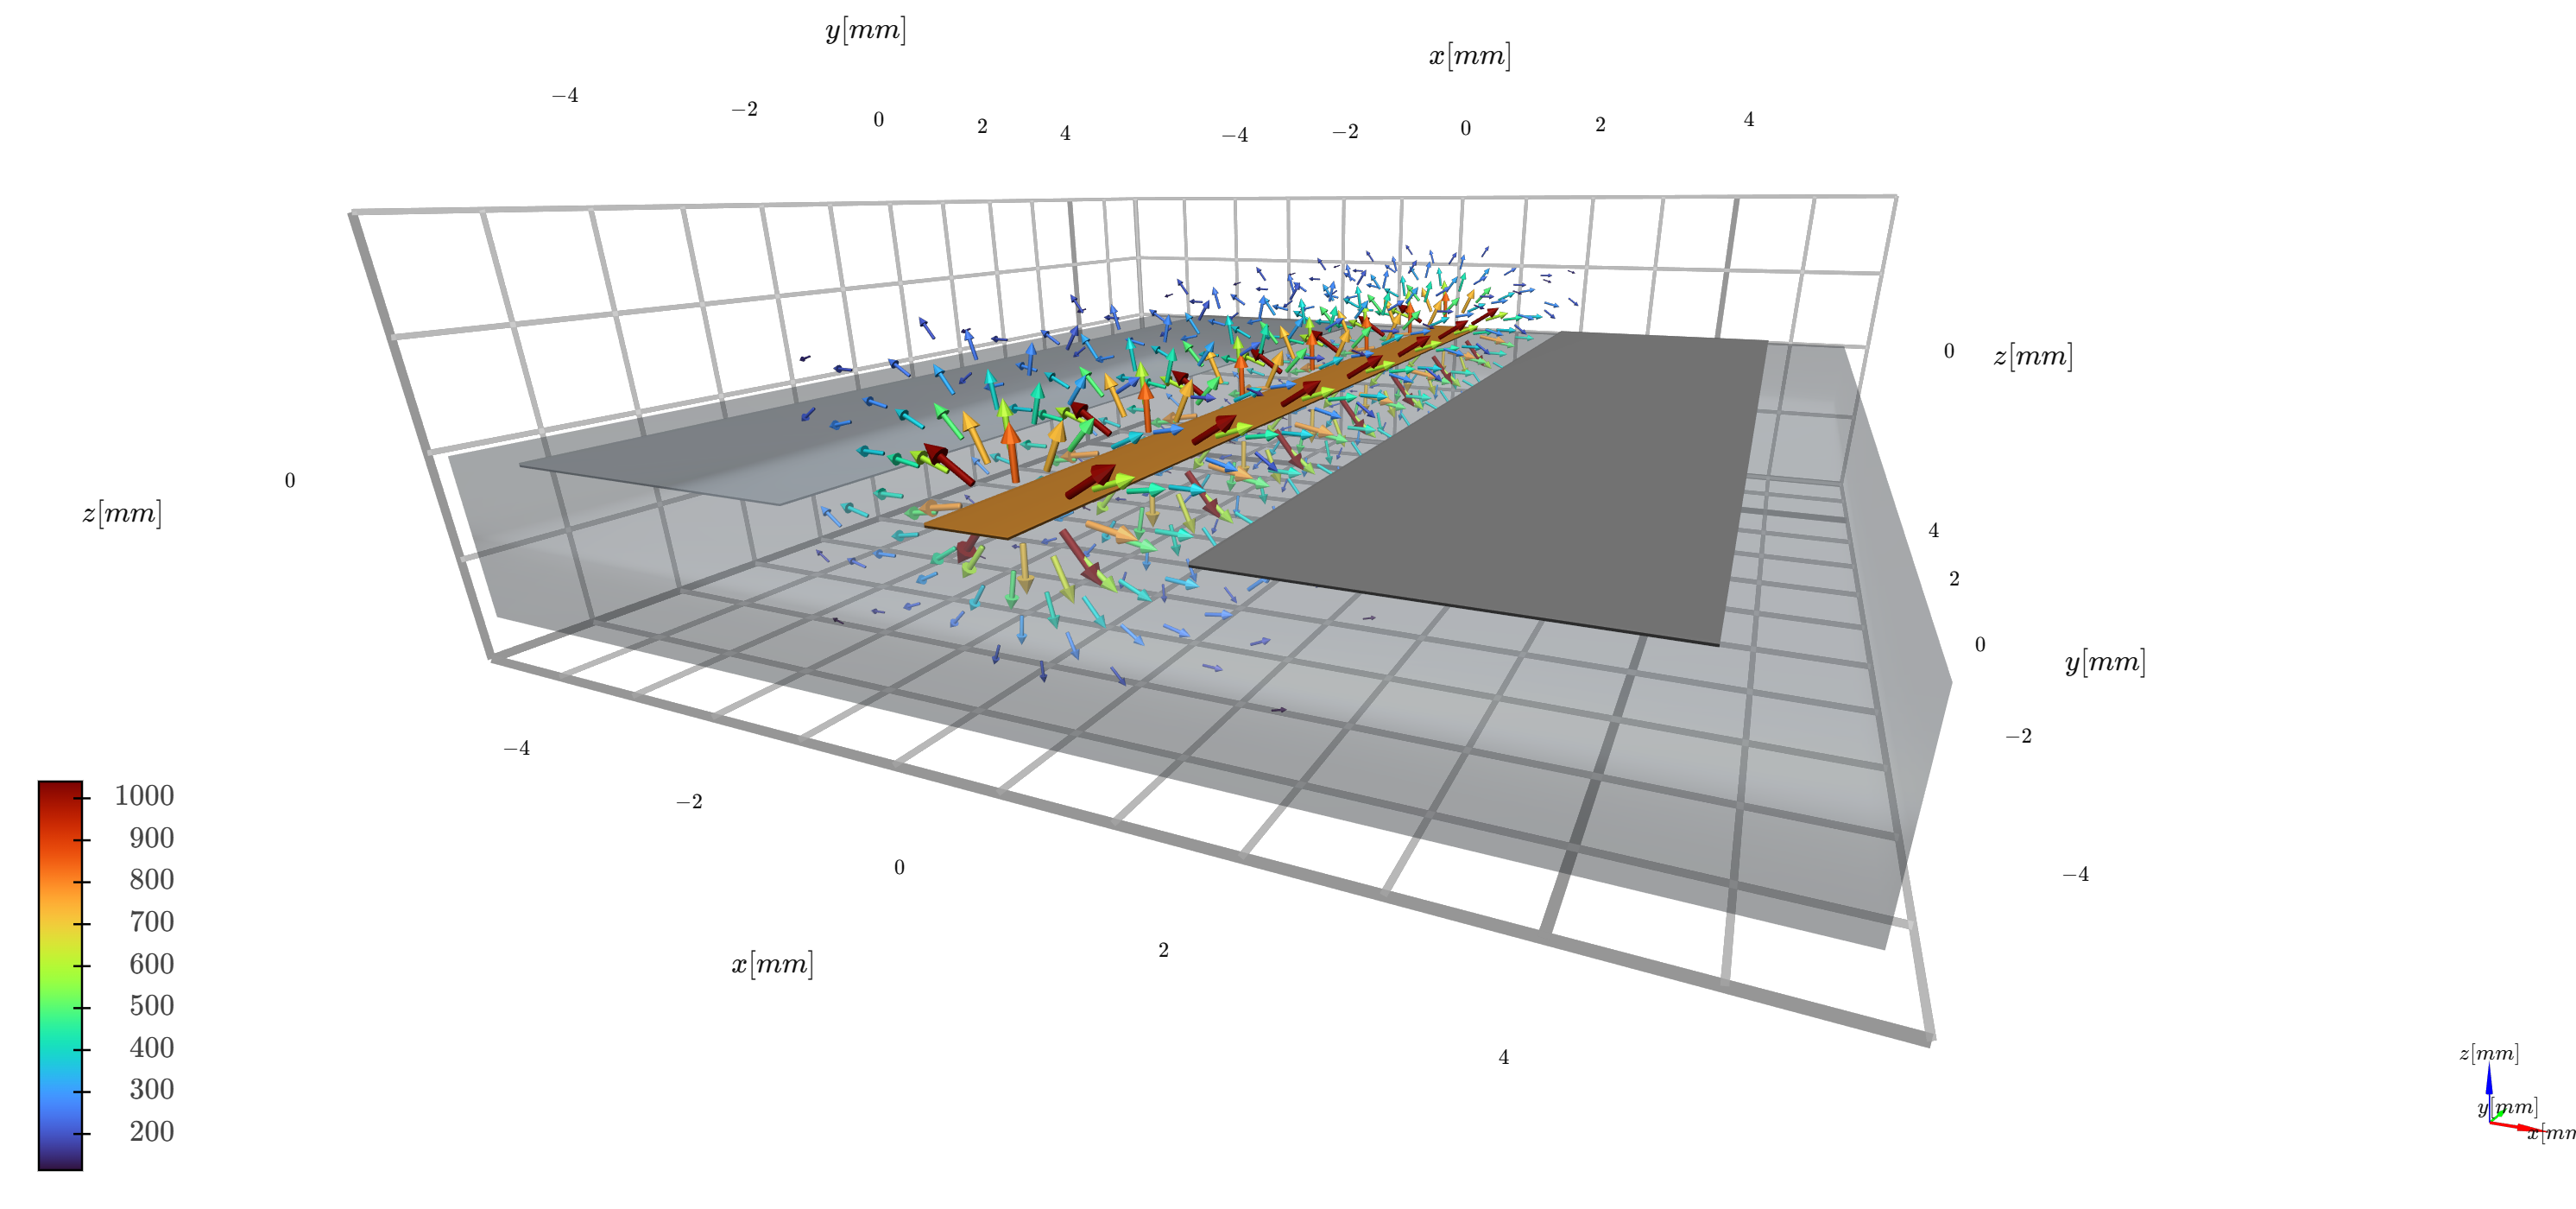

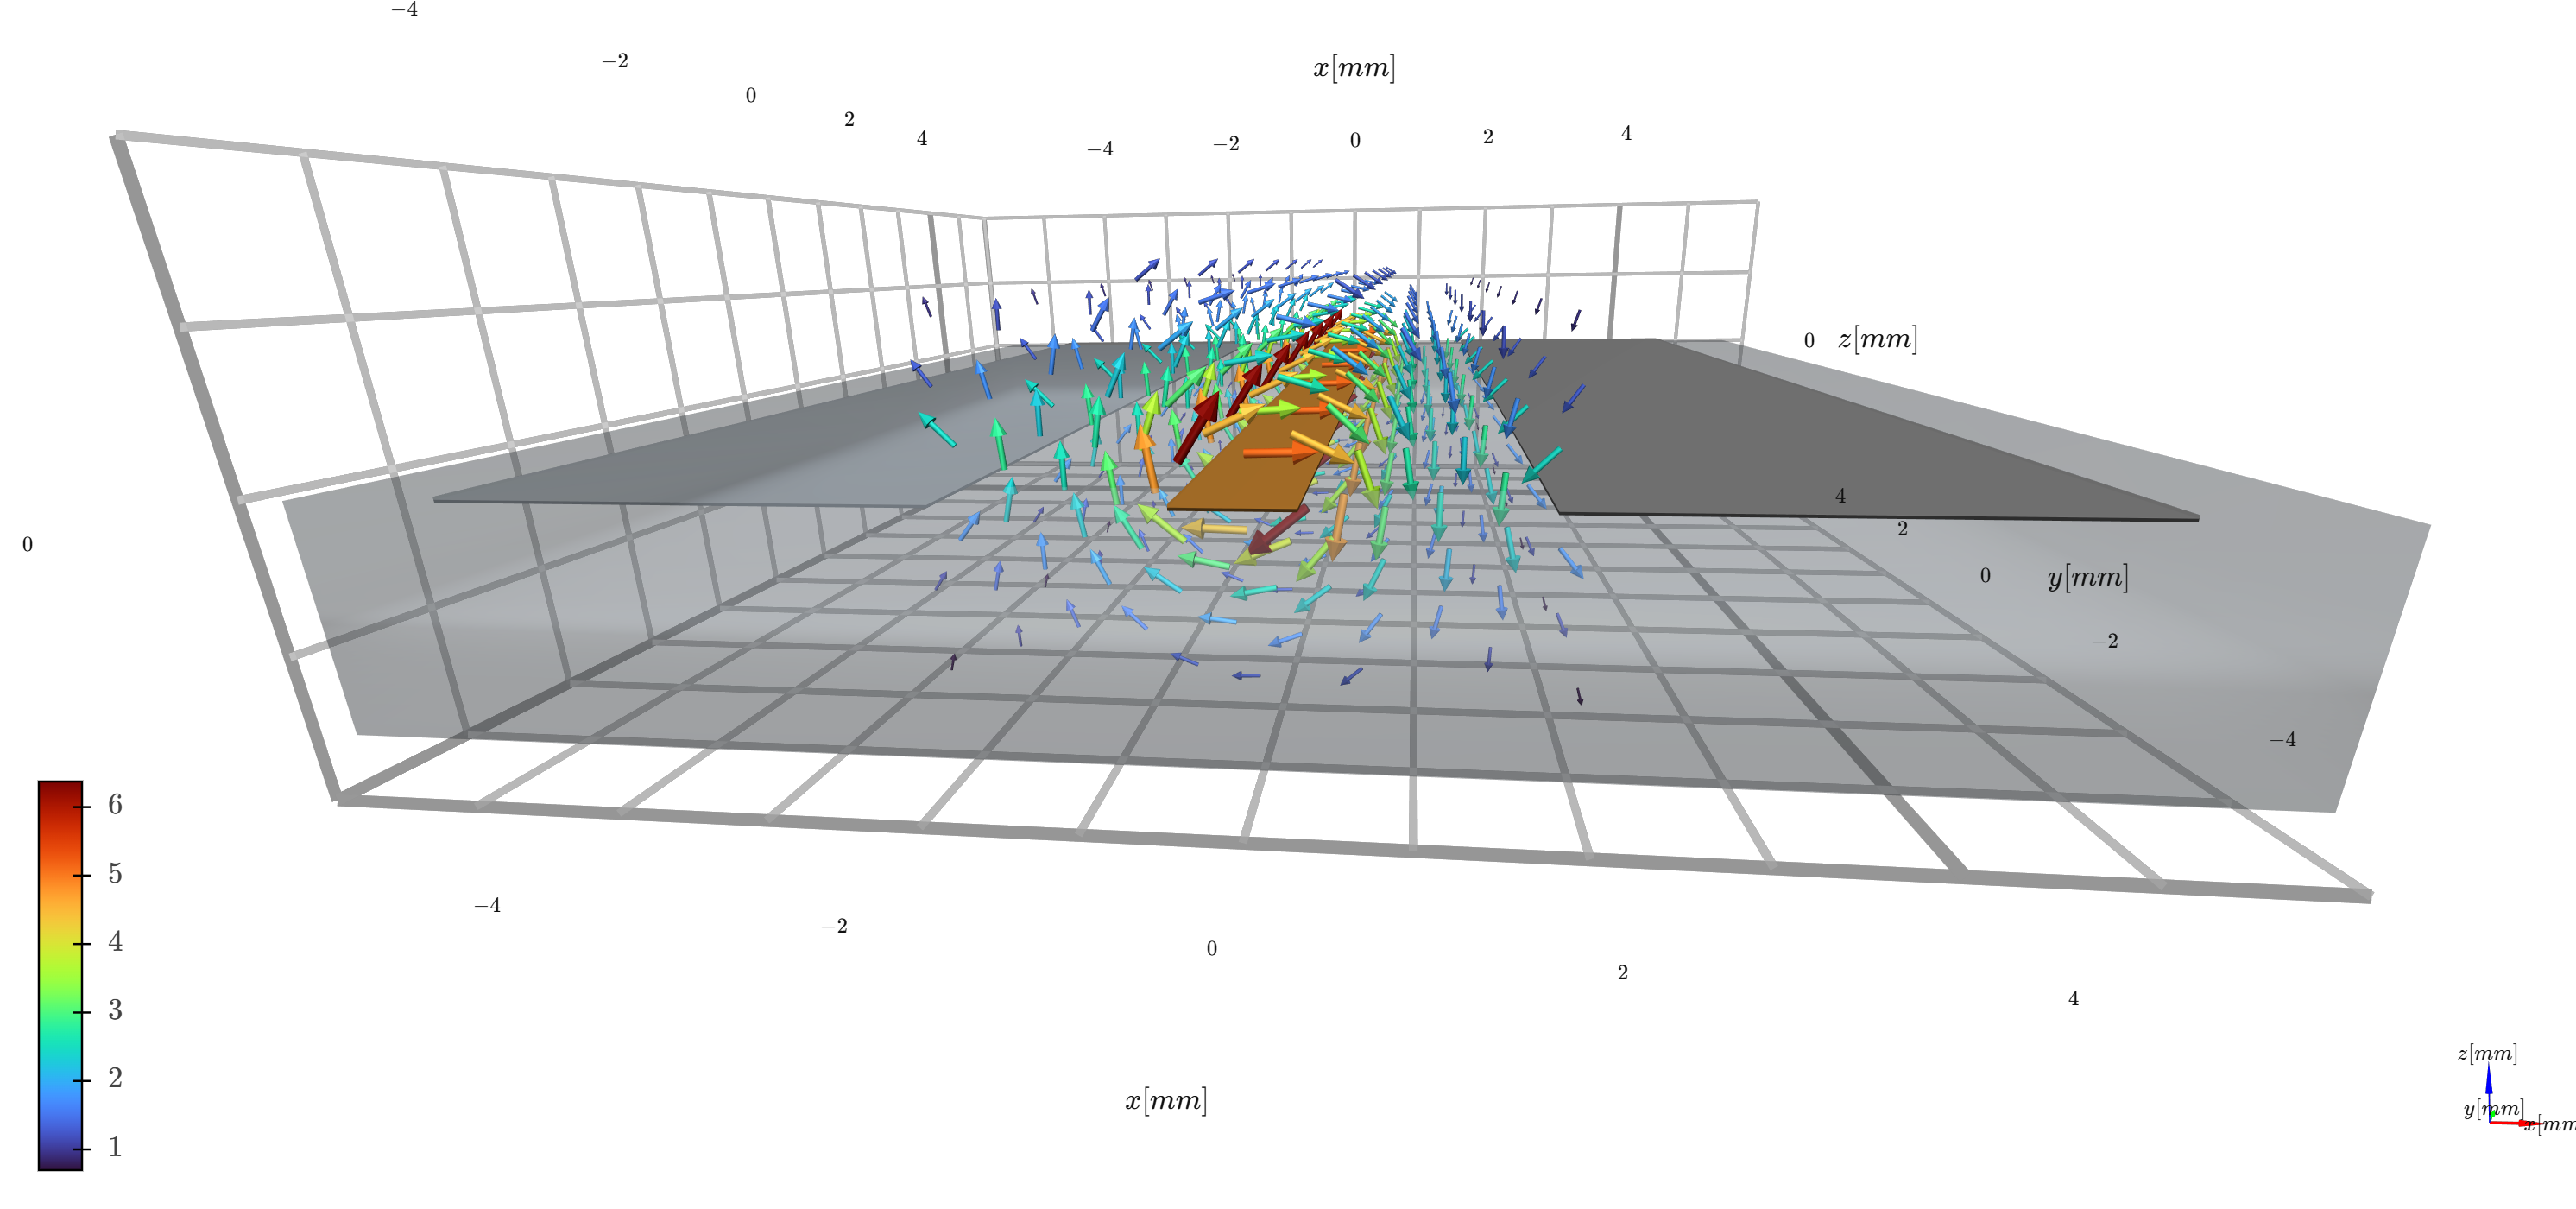